# 13 — Portfolio VaR and Expected Shortfall

This notebook compares CA-RNN with the VAR–GARCH joint-residual bootstrap as downstream portfolio-risk models. It uses the saved forecasts from notebooks 08 and 11, so no model is retrained. Returns are converted to equal-weight portfolio losses. The primary tail is the prespecified 5% upper loss tail (95% VaR).

Expected Shortfall here is a risk measure, not the Energy Score used elsewhere. VaR is assessed with exceedance diagnostics and quantile loss; VaR and Expected Shortfall are assessed jointly with the FZ0 proper score. Lower scores are better. Coverage-test p-values are descriptive under serial dependence; paired conclusions use the hierarchical moving-block bootstrap.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from innovcal.ca_rnn.evaluation import (
    paired_seed_tail_risk_bootstrap,
    portfolio_tail_forecasts,
    summarize_tail_risk,
)

warnings.filterwarnings('ignore', category=RuntimeWarning)
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT = ROOT / 'results' / 'tail_risk'
OUT.mkdir(parents=True, exist_ok=True)
TAIL_PROBABILITY = 0.05
BLOCK_LENGTH = 20
N_BOOTSTRAP = 2000

In [2]:
seed_archive = np.load(ROOT / 'results' / 'seed_uncertainty' / 'seed_forecasts.npz')
seed_manifest = pd.read_csv(ROOT / 'results' / 'seed_uncertainty' / 'seed_forecast_manifest.csv')
baseline_archive = np.load(ROOT / 'results' / 'conventional_baselines' / 'baseline_forecasts.npz')

# The archived manifest predates the final naming convention. Its full
# projected-plus-temporal specification is the model now called CA-RNN.
archived_full_name = 'CA-RNN sequential' if 'CA-RNN sequential' in set(seed_manifest.model) else 'CA-RNN'
ca_key = seed_manifest.loc[seed_manifest.model == archived_full_name, 'array_key'].iloc[0]
target = seed_archive['target'].astype(float)
ca_samples = seed_archive[ca_key].astype(float)
var_garch_samples = baseline_archive['VAR_GARCH_bootstrap'].astype(float)
np.testing.assert_allclose(target, baseline_archive['target'], atol=1e-6)
weights = np.full(target.shape[1], 1.0 / target.shape[1])
print(f'{ca_samples.shape[0]} CA-RNN seeds; {len(target)} matched origins; {ca_samples.shape[1]} draws per seed')
print('Equal portfolio weights:', weights)

10 CA-RNN seeds; 957 matched origins; 500 draws per seed
Equal portfolio weights: [0.25 0.25 0.25 0.25]


In [3]:
rows = []
for seed_index, samples in enumerate(ca_samples):
    rows.append({'model': 'CA-RNN', 'training_seed_index': seed_index, **summarize_tail_risk(
        target, samples, tail_probability=TAIL_PROBABILITY, weights=weights
    )})
rows.append({'model': 'VAR-GARCH bootstrap', 'training_seed_index': np.nan, **summarize_tail_risk(
    target, var_garch_samples, tail_probability=TAIL_PROBABILITY, weights=weights
)})
seed_metrics = pd.DataFrame(rows)
seed_metrics.to_csv(OUT / 'portfolio_tail_risk_by_seed.csv', index=False)
display(seed_metrics)

summary = seed_metrics.groupby('model', sort=False).agg(
    exceedance_rate=('exceedance_rate', 'mean'),
    exceedance_rate_sd=('exceedance_rate', 'std'),
    mean_value_at_risk=('mean_value_at_risk', 'mean'),
    mean_expected_shortfall=('mean_expected_shortfall', 'mean'),
    mean_exceedance_loss=('mean_exceedance_loss', 'mean'),
    mean_quantile_loss=('mean_quantile_loss', 'mean'),
    mean_joint_var_es_score=('mean_joint_var_es_score', 'mean'),
).reset_index()
summary.to_csv(OUT / 'portfolio_tail_risk_summary.csv', index=False)
display(summary)

,model,training_seed_index,n_origins,n_exceedances,exceedance_rate,exceedance_rate_error,mean_value_at_risk,mean_expected_shortfall,mean_exceedance_loss,mean_quantile_loss,mean_joint_var_es_score,kupiec_p_value,independence_p_value,conditional_coverage_p_value
0,CA-RNN,0.0,957.0,57.0,0.059561,0.009561,0.925454,1.155951,1.180060,0.069931,0.335517,0.187122,0.386176,0.287785
1,CA-RNN,1.0,957.0,62.0,0.064786,0.014786,0.889952,1.115282,1.165526,0.068758,0.339541,0.044296,0.570743,0.112665
2,CA-RNN,2.0,957.0,55.0,0.057471,0.007471,0.948468,1.182855,1.213911,0.070637,0.361209,0.299772,0.459582,0.444387
3,CA-RNN,3.0,957.0,62.0,0.064786,0.014786,0.910083,1.133654,1.161693,0.070556,0.381623,0.044296,0.237975,0.065948
4,CA-RNN,4.0,957.0,57.0,0.059561,0.009561,0.936014,1.167689,1.136159,0.069628,0.349514,0.187122,0.386176,0.287785
5,CA-RNN,5.0,957.0,54.0,0.056426,0.006426,0.954674,1.192304,1.222795,0.070390,0.348631,0.371006,0.499281,0.533456
6,CA-RNN,6.0,957.0,60.0,0.062696,0.012696,0.927686,1.159797,1.162190,0.070139,0.349499,0.082451,0.291279,0.126843
7,CA-RNN,7.0,957.0,61.0,0.063741,0.013741,0.908770,1.134153,1.123141,0.069439,0.356946,0.060887,0.263655,0.092434
8,CA-RNN,8.0,957.0,63.0,0.065831,0.015831,0.883078,1.102847,1.131988,0.069575,0.378657,0.031751,0.214186,0.046079
9,CA-RNN,9.0,957.0,49.0,0.051202,0.001202,0.982497,1.224247,1.254361,0.070966,0.336181,0.865068,0.257686,0.519437


,model,exceedance_rate,exceedance_rate_sd,mean_value_at_risk,mean_expected_shortfall,mean_exceedance_loss,mean_quantile_loss,mean_joint_var_es_score
0,CA-RNN,0.060606,0.004647,0.926668,1.156878,1.175182,0.070002,0.353732
1,VAR-GARCH bootstrap,0.039707,NaN,1.061997,1.516738,1.413623,0.069997,0.286565


In [4]:
inference = paired_seed_tail_risk_bootstrap(
    target,
    ca_samples,
    var_garch_samples,
    tail_probability=TAIL_PROBABILITY,
    weights=weights,
    block_length=BLOCK_LENGTH,
    n_bootstrap=N_BOOTSTRAP,
    seed=13_013,
)
inference.to_csv(OUT / 'portfolio_tail_risk_inference.csv', index=False)
display(inference)
print('Differences are CA-RNN minus VAR-GARCH; negative proper-score differences favor CA-RNN.')

,n_seeds,n_origins,block_length,n_bootstrap,candidate,comparator,metric,difference,bootstrap_se,ci_lower,ci_upper,probability_difference_below_zero
0,10,957,20,2000,CA-RNN,VAR-GARCH bootstrap,quantile_loss,0.000004,0.000604,-0.001082,0.001300,0.417
1,10,957,20,2000,CA-RNN,VAR-GARCH bootstrap,joint_var_es_score,0.067166,0.020060,0.030795,0.110496,0.000


Differences are CA-RNN minus VAR-GARCH; negative proper-score differences favor CA-RNN.


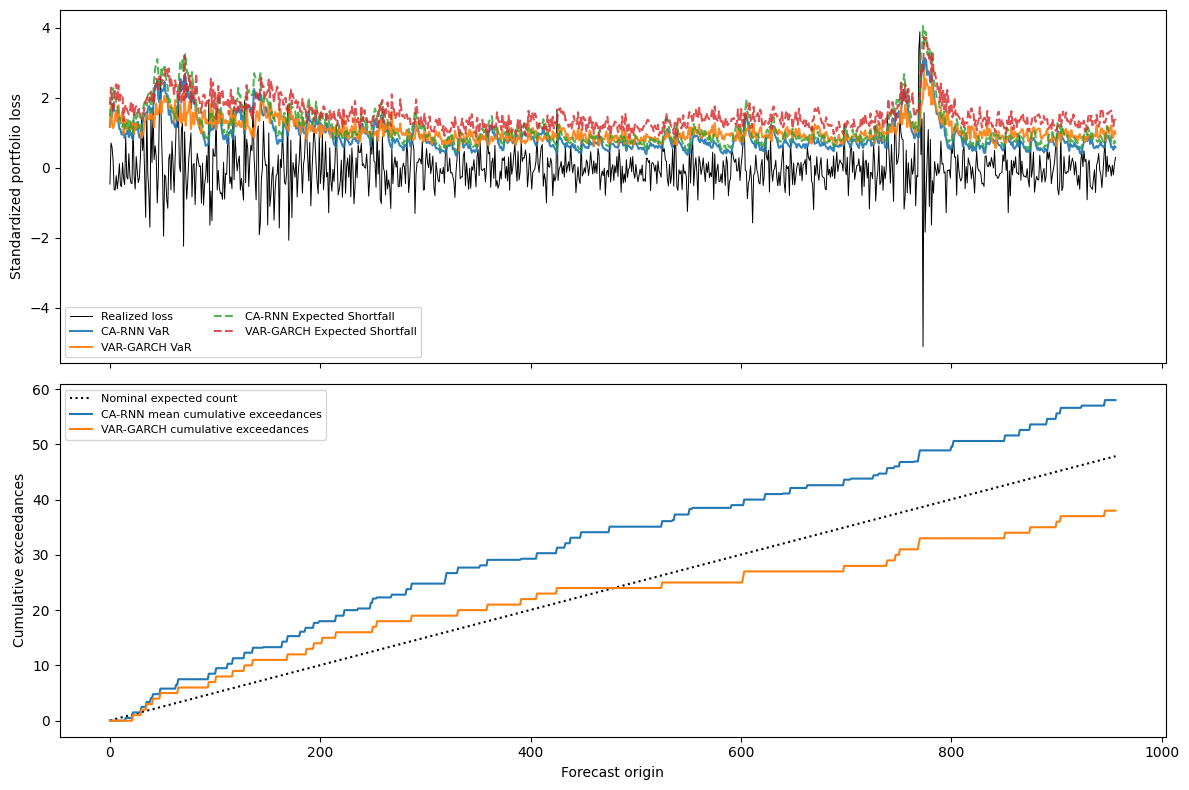

In [5]:
ca_paths = [portfolio_tail_forecasts(target, value, tail_probability=TAIL_PROBABILITY, weights=weights) for value in ca_samples]
vg_path = portfolio_tail_forecasts(target, var_garch_samples, tail_probability=TAIL_PROBABILITY, weights=weights)
ca_var = np.mean([frame.value_at_risk.to_numpy() for frame in ca_paths], axis=0)
ca_es = np.mean([frame.expected_shortfall.to_numpy() for frame in ca_paths], axis=0)
loss = vg_path.realized_loss.to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(loss, color='black', linewidth=0.7, label='Realized loss')
axes[0].plot(ca_var, label='CA-RNN VaR', alpha=0.9)
axes[0].plot(vg_path.value_at_risk, label='VAR-GARCH VaR', alpha=0.9)
axes[0].plot(ca_es, '--', label='CA-RNN Expected Shortfall', alpha=0.8)
axes[0].plot(vg_path.expected_shortfall, '--', label='VAR-GARCH Expected Shortfall', alpha=0.8)
axes[0].set_ylabel('Standardized portfolio loss')
axes[0].legend(ncol=2, fontsize=8)

expected = TAIL_PROBABILITY * np.arange(1, len(target) + 1)
ca_hits = np.mean([np.cumsum(frame.exceedance) for frame in ca_paths], axis=0)
axes[1].plot(expected, color='black', linestyle=':', label='Nominal expected count')
axes[1].plot(ca_hits, label='CA-RNN mean cumulative exceedances')
axes[1].plot(np.cumsum(vg_path.exceedance), label='VAR-GARCH cumulative exceedances')
axes[1].set_xlabel('Forecast origin')
axes[1].set_ylabel('Cumulative exceedances')
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / 'portfolio_tail_risk_paths.png', dpi=180, bbox_inches='tight')
plt.show()

## Interpretation rules

A VaR exceedance rate near 0.05 is necessary but not sufficient: inspect clustering and quantile loss as well. Lower FZ0 joint score indicates a better VaR–Expected Shortfall pair. Treat the Kupiec and independence p-values as descriptive because daily forecast errors are dependent and the models are estimated. The hierarchical interval is the principal comparison: it resamples CA-RNN optimization seeds and matched moving blocks of forecast origins while conditioning on the single fitted VAR–GARCH benchmark. This notebook is exploratory and does not alter the frozen confirmatory protocol.